<a href="https://colab.research.google.com/github/narayananxyz/deep_learning/blob/main/FDS_Project_LearnerNotebook_FullCode_Narayanan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Mount the drive to load the file (ignore if running locally)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Understanding the structure of the data

In [ ]:
# read the data. Please replace path with appropriate path.
path = '/content/drive/MyDrive/mitcourse/project1/foodhub_order.csv'
df = pd.read_csv(path)
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
total_rows, total_cols = df.shape
print(f"Total rows: {total_rows}")
print(f"Total columns: {total_cols}")

Total rows: 1898
Total columns: 9


#### Observations:
The dataset has 1989 rows and 9 columns.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
day of the week and rating are pbject types. So, need some processing before doing math operations on them.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

#### Observations:
Even though the df.info() does not show it. The rating column seems to have some "not given". This can be treated.

In [ ]:
unrated_orders = df[df['rating'] == 'Not given'].shape[0]
print(f"Number of orders not rated: {unrated_orders}")

Number of orders not rated: 736


#### Treatment of Missing Values in 'rating' column:
##### Two Options:
##### Option1:
Looks like pandas can already handle NaN for mean and other calculations. So Just marking them NaN will might work for most cases.


In [ ]:
# Before touching create a copy
df_copy = df.copy()

# Convert 'rating' to numeric, coercing 'Not given' to NaN
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df.describe()


,order_id,customer_id,cost_of_the_order,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1162.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,4.344234,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,0.741478,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,3.000000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,4.000000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,5.000000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,5.000000,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,5.000000,35.000000,33.000000


##### Option2:
Step 1: Replace with restaurent mean. It will not be right to replace with a full mean as the a good rated restaurant should not influence a badly rated restaurant. Hence caluclate mean at restaurant level and do it.

In [ ]:
# Calculate the mean rating for each restaurant
mean_ratings_by_restaurant = df.groupby('restaurant_name')['rating'].transform('mean')

# Fill NaN values in 'rating' with the mean rating of their respective restaurant
df['rating'].fillna(mean_ratings_by_restaurant, inplace=True)

# Round the ratings to 1 decimal place
df['rating'] = df['rating'].round(1)

# Verify that there are no more 'Not given' values or NaNs in the 'rating' column
print(f"Number of remaining missing ratings (NaN): {df['rating'].isnull().sum()}")
print(f"Number of 'Not given' strings in rating column (should be 0): {df[df['rating'] == 'Not given'].shape[0]}")

# Display first few rows to check the updated 'rating' column
df.describe()

Number of remaining missing ratings (NaN): 30
Number of 'Not given' strings in rating column (should be 0): 0


/tmp/ipykernel_838/1821096314.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(mean_ratings_by_restaurant, inplace=True)


,order_id,customer_id,cost_of_the_order,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1868.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,4.348233,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,0.611576,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,3.000000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,4.000000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,4.300000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,5.000000,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,5.000000,35.000000,33.000000


Step 2: But, there are some restaurants with no rating at all. Those are still NaN. They can be replaced with average mean.

In [ ]:
# Calculate the overall mean rating of the 'rating' column (excluding existing NaN values)
overall_mean_rating = df['rating'].mean()

# Fill remaining NaN values in 'rating' with the overall mean rating
df['rating'].fillna(overall_mean_rating, inplace=True)

# Round the ratings to 1 decimal place again to ensure consistency
df['rating'] = df['rating'].round(1)

# Verify that there are no more NaN values in the 'rating' column
print(f"Number of remaining missing ratings (NaN) after second imputation: {df['rating'].isnull().sum()}")

# Display first few rows to check the updated 'rating' column
df.describe()

Number of remaining missing ratings (NaN) after second imputation: 0


/tmp/ipykernel_838/136806982.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(overall_mean_rating, inplace=True)


,order_id,customer_id,cost_of_the_order,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,4.347471,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,0.606750,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,3.000000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,4.000000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,4.300000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,5.000000,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,5.000000,35.000000,33.000000


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
df.describe()

,order_id,customer_id,cost_of_the_order,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,4.347471,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,0.606750,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,3.000000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,4.000000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,4.300000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,5.000000,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,5.000000,35.000000,33.000000


#### Observations:


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
unrated_orders = df[df['rating'] == 'Not given'].shape[0]
print(f"Number of orders not rated: {unrated_orders}")

Number of orders not rated: 0


#### Observations:
Since I handled the not rated ones before. There is none in this step. However to answer this question, There were 736 Not rated ones

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [ ]:
#creating a definition that a lof of visulations can be made easily.
def univariate_analysis(df, column):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(column)

    is_numeric = pd.api.types.is_numeric_dtype(df[column])

    if is_numeric:
        sns.histplot(df[column], kde=True, ax=axes[0])
        sns.boxplot(y=df[column], ax=axes[1])
        sns.kdeplot(df[column], ax=axes[2])
    else:
        order = df[column].value_counts().index
        sns.countplot(x=df[column], order=order, ax=axes[0])
        sns.countplot(x=df[column], order=order, ax=axes[1])
        df[column].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[2])

    plt.tight_layout()
    plt.show()

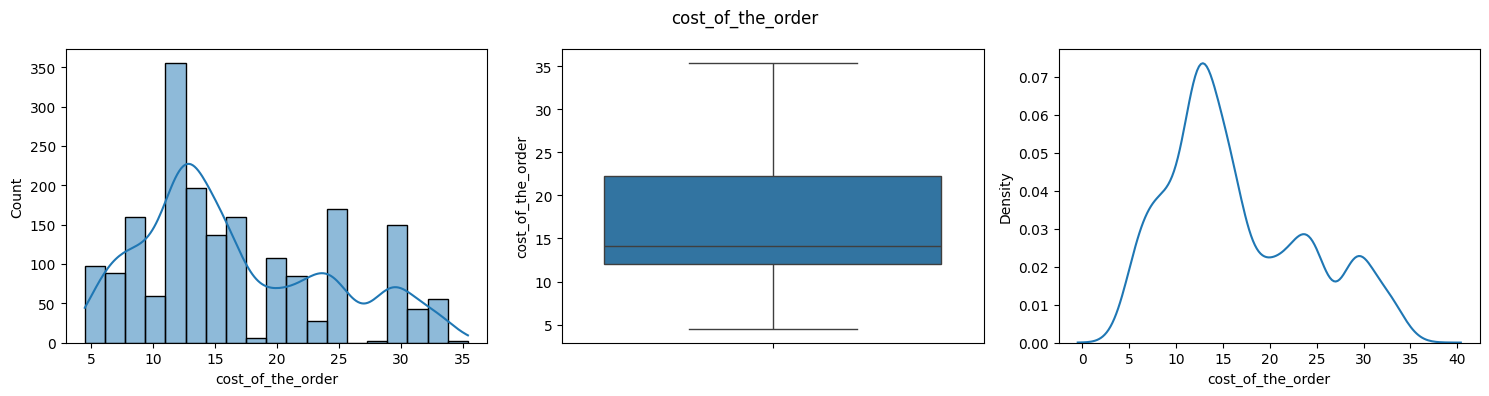

In [ ]:
univariate_analysis(df, 'cost_of_the_order')

#### Observation:
The mean is less than 15 and the data seems to have mostly around 13-25

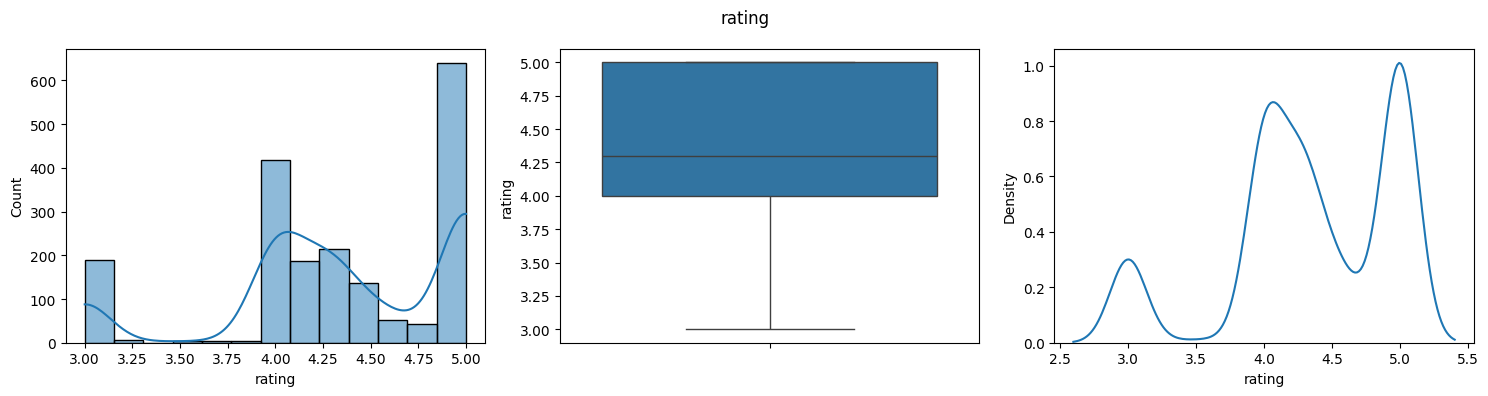

In [ ]:
univariate_analysis(df, 'rating')

### Observation
Mean is around 4.3 hence it is left skewed

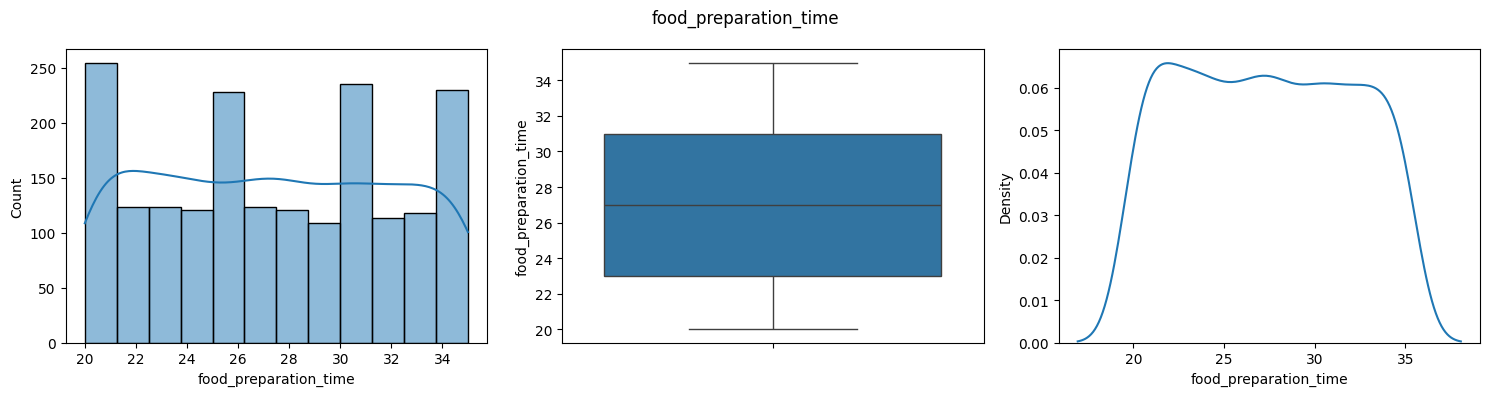

In [ ]:
univariate_analysis(df, 'food_preparation_time')

### Observation
This is uniform distribution..

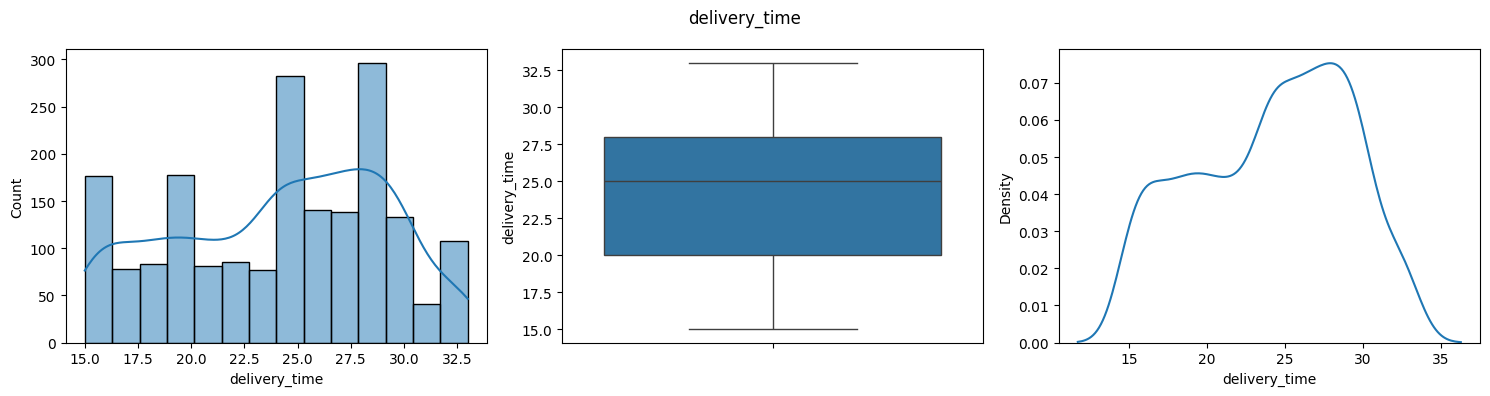

In [ ]:
univariate_analysis(df, 'delivery_time')

### Observation

The range here is much higher 15 to 32 when compared to food preparation time. This is probably due to the variance in delivery or restaurant addresses.

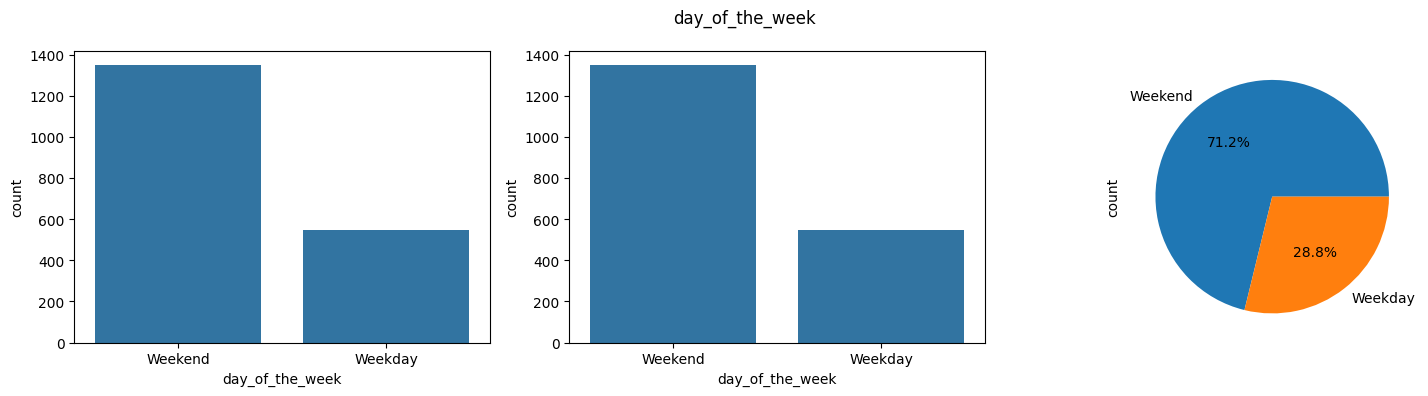

In [ ]:
univariate_analysis(df, 'day_of_the_week')

### Observation

Data shows more orders in weekend vs weekday.

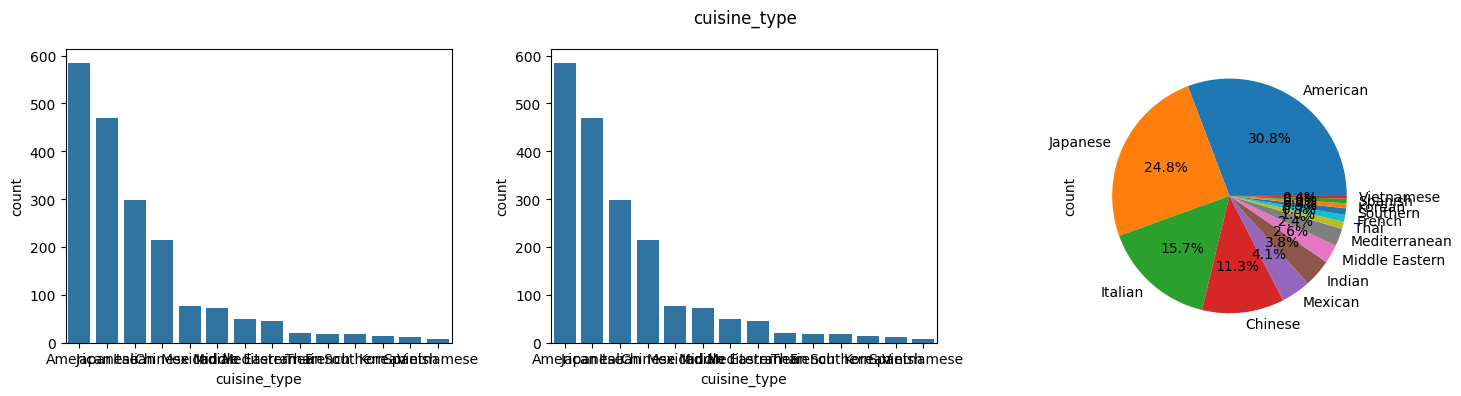

In [ ]:
univariate_analysis(df, 'cuisine_type')

### Observation:
American is highest odered, followed by japanese and italian.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
df['restaurant_name'].value_counts().head(5)


,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
weekend = df[df['day_of_the_week'] == 'Weekend']
weekend['cuisine_type'].value_counts().head(1)

,count
cuisine_type,
American,415


#### Observations:


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
above_20 = df[df['cost_of_the_order'] > 20]
percentage = (len(above_20) / len(df)) * 100
print(f'{percentage:.2f}%')

29.24%


#### Observations: 29.24% which means there are a lot of smaller orders


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
df['delivery_time'].mean()

np.float64(24.161749209694417)

#### Observations:
24 minutes is the mean

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
df['customer_id'].value_counts().head(3)


,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


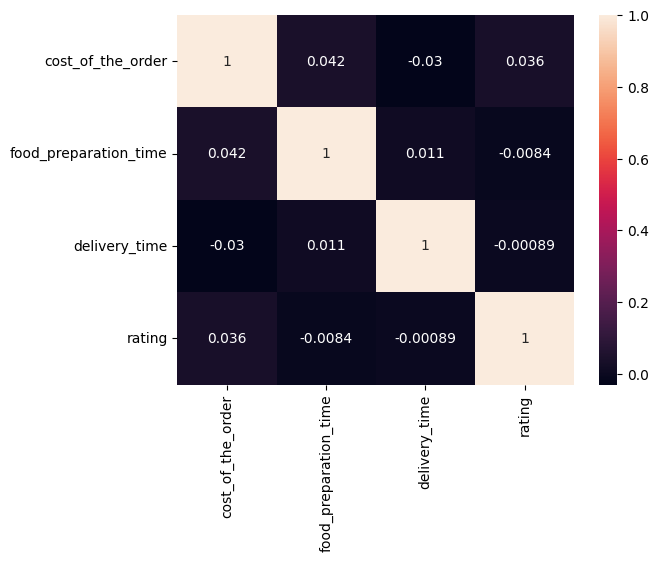

In [ ]:
sns.heatmap(df[['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']].corr(), annot=True)
plt.show()

### Observation:
There is not much of a positive of negative co-relation between the numerical values of the data. One possible reason could be due to syntetic data which is evenly spread.

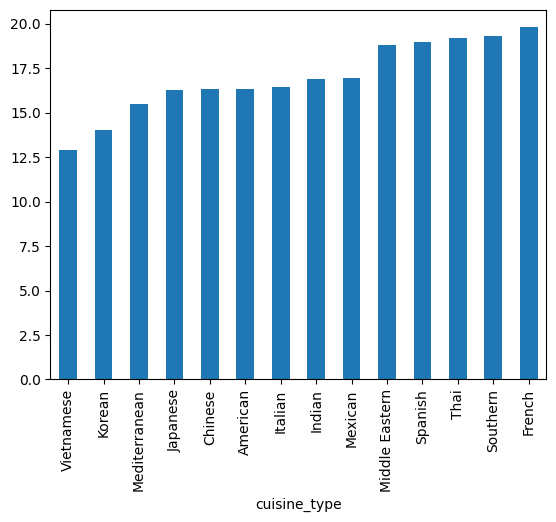

In [ ]:
df.groupby('cuisine_type')['cost_of_the_order'].mean().sort_values().plot(kind='bar')
plt.show()

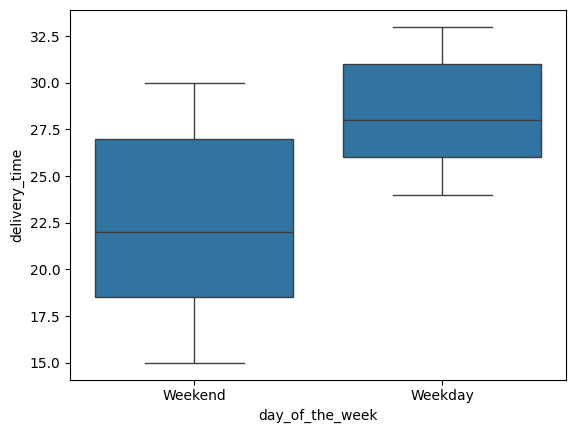

In [ ]:
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.show()

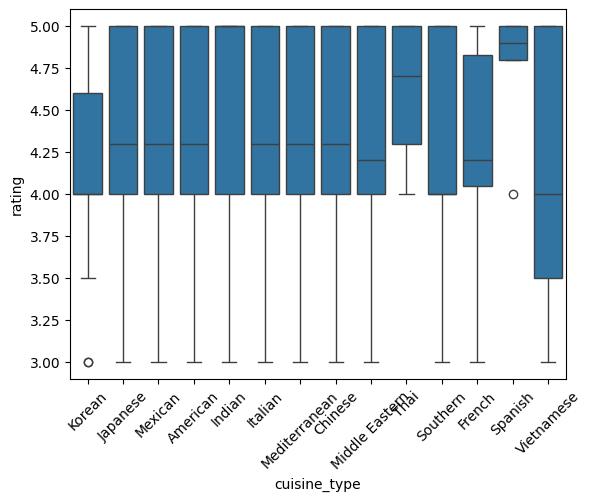

In [ ]:
sns.boxplot(x='cuisine_type', y='rating', data=df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
print(df[['total_time', 'rating']].corr())

            total_time    rating
total_time    1.000000 -0.006368
rating       -0.006368  1.000000


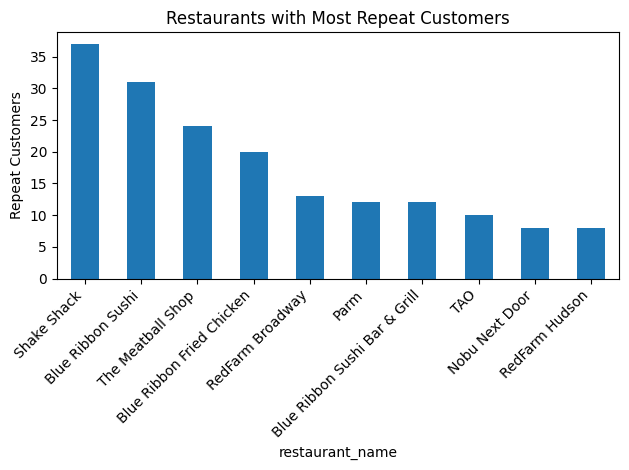

In [ ]:
repeat = df.groupby(['restaurant_name', 'customer_id']).size().reset_index(name='orders')
repeat = repeat[repeat['orders'] > 1]
repeat_count = repeat.groupby('restaurant_name')['customer_id'].count().sort_values(ascending=False).head(10)

repeat_count.plot(kind='bar')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Repeat Customers')
plt.title('Restaurants with Most Repeat Customers')
plt.tight_layout()
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
#for this let's work on the copy as they want us to look at specific rating count..
# so we should not use the data where we have filled the missing data.
df_copy['rating'] = pd.to_numeric(df_copy['rating'], errors='coerce')
df_copy.describe()

grouped = df_copy.groupby('restaurant_name')['rating']
promo = grouped.agg(['count', 'mean'])
promo = promo[(promo['count'] > 50) & (promo['mean'] > 4)]
print(promo)

                           count      mean
restaurant_name                           
Blue Ribbon Fried Chicken     64  4.328125
Blue Ribbon Sushi             73  4.219178
Shake Shack                  133  4.278195
The Meatball Shop             84  4.511905


#### Observations: I worked on the copy of data so that we get a accurate count of the rating before we filled the missing ratings


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
high = df[df['cost_of_the_order'] > 20]['cost_of_the_order'].sum() * 0.25
mid  = df[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20)]['cost_of_the_order'].sum() * 0.15

print(f'Net Revenue: ${high + mid:.2f}')

Net Revenue: $6166.30


#### Observations:


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

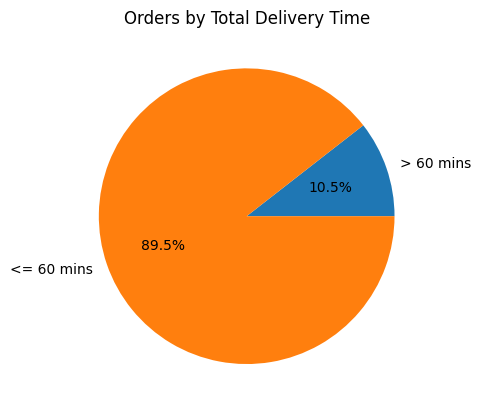

In [ ]:
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
over_60 = (df['total_time'] > 60).sum()
under_60 = (df['total_time'] <= 60).sum()

plt.pie([over_60, under_60], labels=['> 60 mins', '<= 60 mins'], autopct='%1.1f%%')
plt.title('Orders by Total Delivery Time')
plt.show()

In [ ]:
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
over_60 = df[df['total_time'] > 60]
print(f'Average rating of orders > 60 mins: {over_60["rating"].mean():.2f}')

Average rating of orders > 60 mins: 4.35


#### Observations:


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

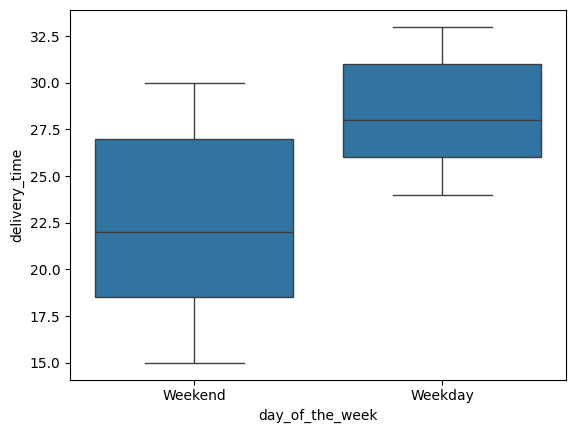

In [ ]:
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.show()

#### Observations: The weekday deliver time mean is much higher than weekend. Traffic data can be observed further to understand if it is due to traffic.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  Weekend delivery times are much shorter than weekday delivery times.
*  American cusine is the highest ordered. Demography data can be further check to understand this better.
*  French cusine has the highest order price.
*  Ratings are generally skewed towards higher numbers.
*  10% of orders have taken greater than 60 minutes to deliver.

### Recommendations:

*  The orders that have taken over 60 minutes can be further analyzed.
*  Repeat customer promotions can be extended to customers who have not ordered for a long time.
*  See if any further improvements are possible Deivery times in weekdays by implementing a express option where toll roads could be used at a additional cost.
* Try to see if the deivery and restaurant can be rated seperated which will help in better analysis.
* Can we capture the driver arrival time to see if any delays in food prep after driver arrival or is the driver arriving after the food is done losing some efficiency. capturing this data will help in more accuracy.
* Can you also capture the distance travelled so that data can be seggregated better for analysis.

---